In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
match = pd.read_csv("match.csv")
delivery = pd.read_csv("deliveries.csv")

In [55]:
match=match.dropna(subset=['winner'])

Toss winners won the match 50.7% of the time


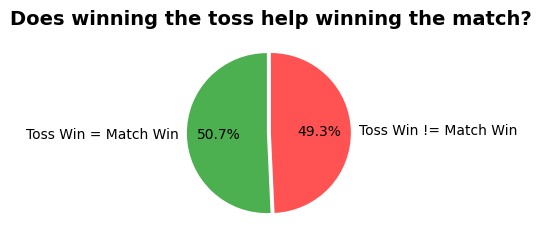

In [56]:
#toss vs win
match['toss_match_win']=match['toss_winner']==match['winner']

toss_effect=match['toss_match_win'].value_counts()

toss_pct=match['toss_match_win'].mean()*100
print(f"Toss winners won the match{toss_pct: .1f}% of the time")


#plot

plt.figure(figsize=(5,5))
plt.pie(match['toss_match_win'].value_counts().values,labels=['Toss Win = Match Win','Toss Win != Match Win'],colors=['#4CAF50','#FF5252'],explode=(0.05,0),autopct='%1.1f%%',startangle=90)
plt.title("Does winning the toss help winning the match?",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('toss_vs_win.png',dpi=150,bbox_inches='tight')
plt.show()

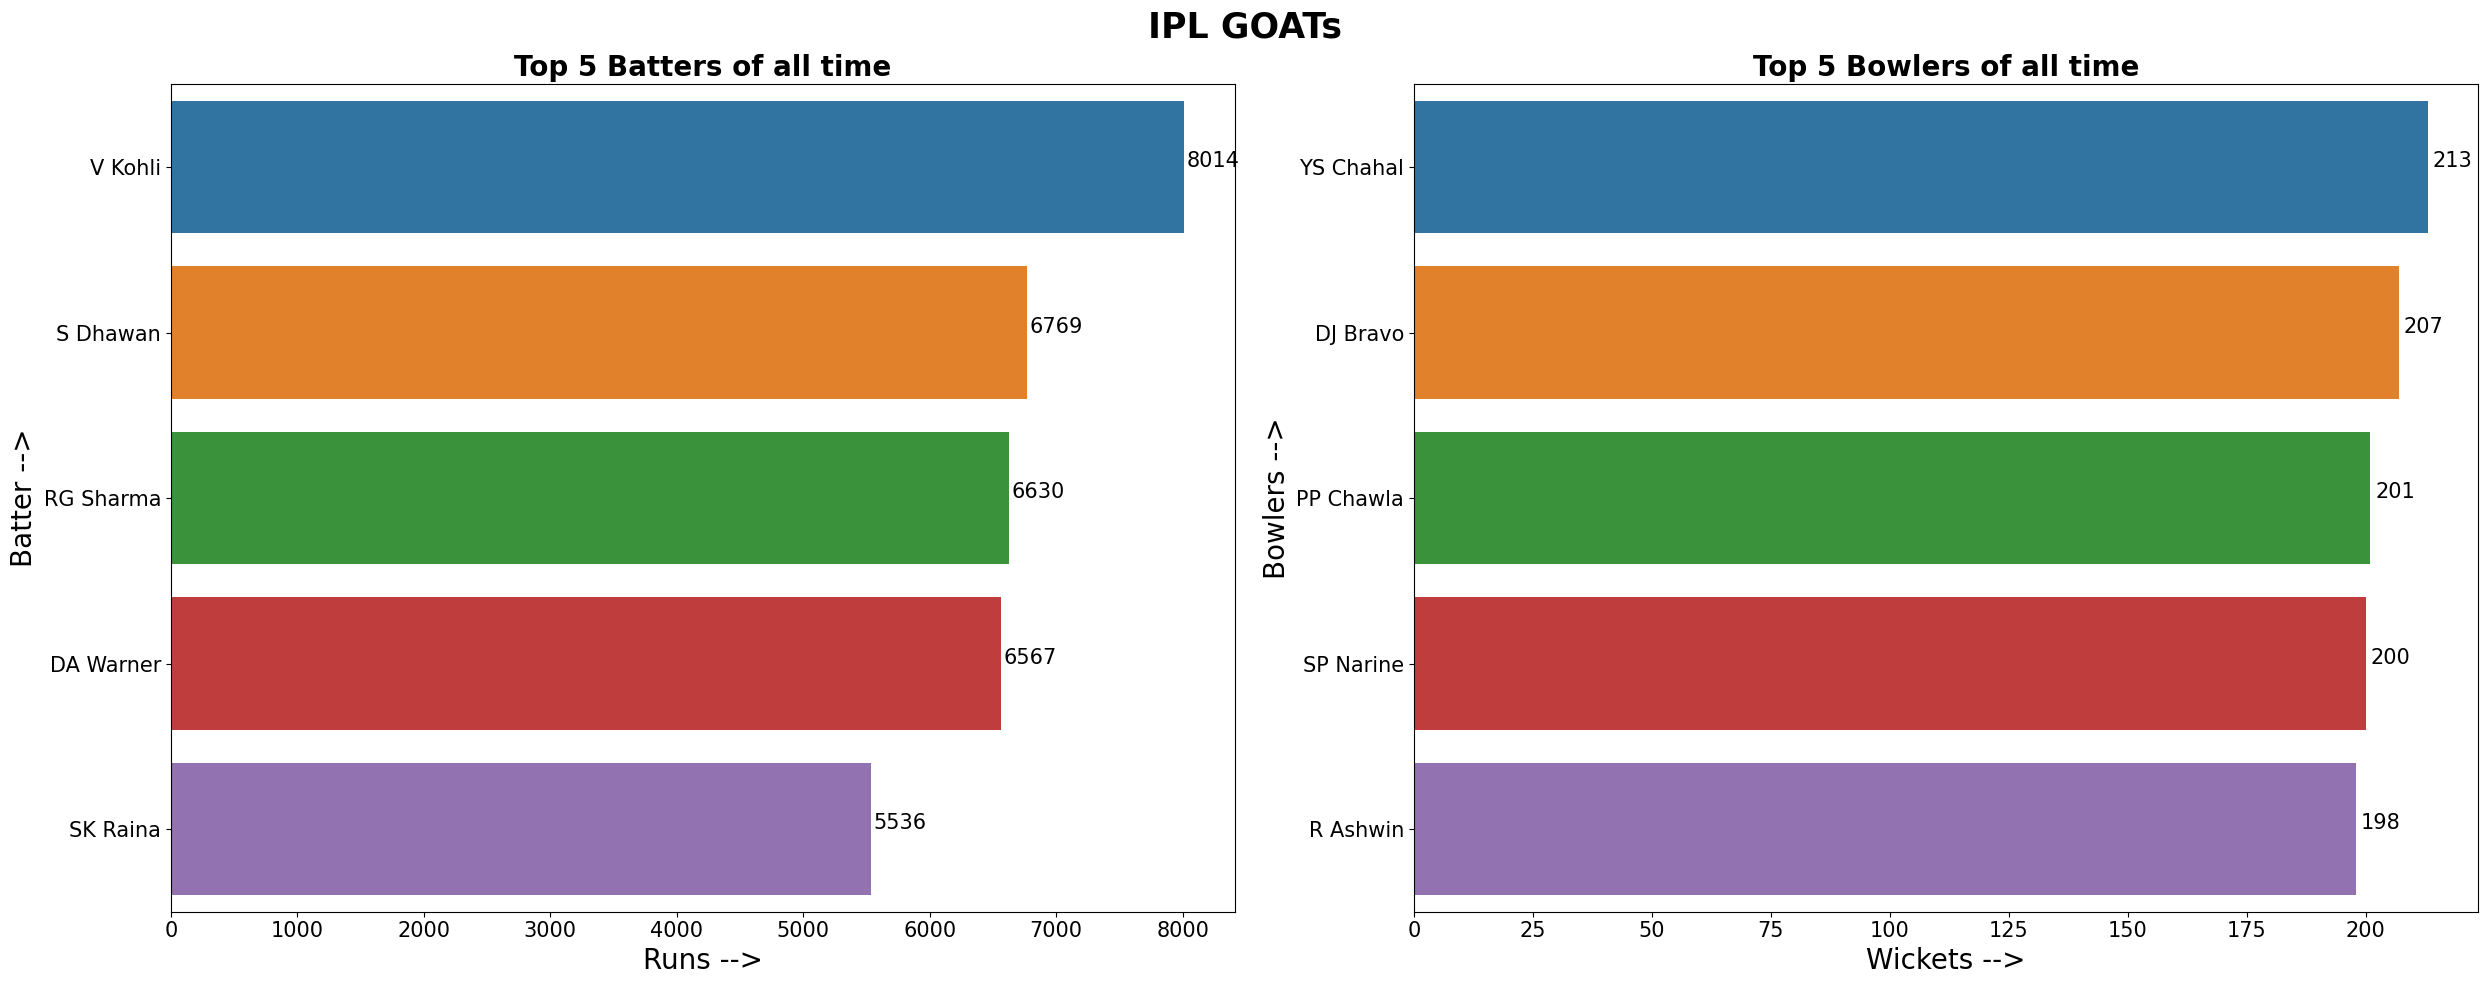

In [57]:
#top 5 run scorers of all time and top 5 wicket takers
top_scorers = delivery.groupby('batter')['batsman_runs'].sum().reset_index()

top_scorers.columns=['batter','total_runs']

top_scorers=top_scorers.sort_values('total_runs', ascending=False).head(5)

top_takers =delivery.groupby('bowler')['is_wicket'].sum().reset_index()
top_takers=top_takers.sort_values('is_wicket',ascending=False).head(5)

#plot
fig, (ax1,ax2)= plt.subplots(1,2,figsize=(25,10))
##left graph
sns.barplot(x=top_scorers.total_runs,y=top_scorers.batter,hue=top_scorers.batter,ax=ax1)
ax1.set_title('Top 5 Batters of all time',fontsize=20,fontweight='bold')
ax1.set_xlabel('Runs -->',fontsize=20)
ax1.set_ylabel('Batter -->',fontsize=20)
for i,v in enumerate(top_scorers['total_runs']):
    ax1.text(v+18,i,str(v),fontsize=15)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
#right graph
sns.barplot(x=top_takers.is_wicket,y=top_takers.bowler,hue=top_takers.bowler,ax=ax2)
ax2.set_title('Top 5 Bowlers of all time',fontsize=20,fontweight='bold')
ax2.set_xlabel('Wickets -->',fontsize=20)
ax2.set_ylabel('Bowlers -->',fontsize=20)
for i,v in enumerate(top_takers['is_wicket']):
    ax2.text(v+1,i,str(v),fontsize=15)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)

fig.suptitle('IPL GOATs',fontsize=25,fontweight='bold')
plt.tight_layout()
plt.savefig('top_goats_IPL.png',dpi=150,bbox_inches='tight')
plt.show()

C:\Users\pingp\AppData\Local\Temp\ipykernel_15040\3210321910.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=venue_avg.target_runs,y=venue_avg.venue,palette=color)


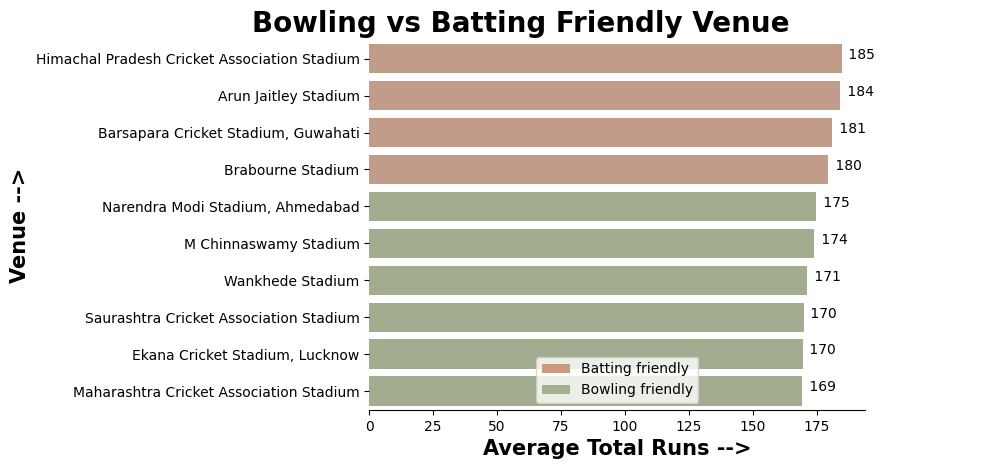

In [61]:
# venue analysis

venue_avg= match.groupby('venue')['target_runs'].mean().reset_index()
venue_avg= venue_avg.sort_values('target_runs',ascending=False).head(10)
overall_avg=venue_avg['target_runs'].mean()
#plot

plt.Figure(figsize=(12,8))
color=['#cb997e'if r>overall_avg else '#a3b18a' for r in venue_avg['target_runs']]
sns.barplot(x=venue_avg.target_runs,y=venue_avg.venue,palette=color)
plt.title("Bowling vs Batting Friendly Venue                    ",fontsize=20,fontweight='bold')
plt.xlabel("Average Total Runs -->",fontsize=15,fontweight='bold')
plt.ylabel("Venue -->",fontsize=15,fontweight='bold')

for i,v in enumerate(venue_avg['target_runs']):
    plt.text(v+1,i,f'{v: .0f}')

from matplotlib.patches import Patch
leg_elements=[
    Patch(facecolor='#cb997e',label='Batting friendly'),
    Patch(facecolor='#a3b18a',label='Bowling friendly')
]
plt.legend(handles=leg_elements,loc='lower center')

sns.despine(left=True,right=True)
plt.savefig('venue_analysis.png',dpi=150,bbox_inches='tight')
plt.show()